# Train Plant/Crop Recommendation Model using Deep Learning (Keras/TensorFlow)

This notebook trains a feedforward neural network to recommend crops based on soil and climate inputs. It saves the trained model, preprocessing models, and training history.

In [1]:
import numpy as np
import pandas as pd
import os
import json
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Ensure models directory exists
os.makedirs('models', exist_ok=True)

### 1. Load and Explore the Dataset

In [2]:
# Load dataset
df = pd.read_csv('data/crop_recommendation.csv')
print("Dataset Shape:", df.shape)
print("Crops Available:", df['label'].nunique())
df.head()

Dataset Shape: (18000, 8)
Crops Available: 36


,N,P,K,temperature,humidity,ph,rainfall,label
0,94.425665,39.059314,35.720357,30.722140,80.018328,5.764603,193.023787,rice
1,92.124350,50.082299,38.292415,26.778102,88.012377,6.391066,175.063183,rice
2,82.301937,37.915523,41.331554,27.411478,80.401103,6.501570,199.534974,rice
3,87.990998,59.348935,44.659623,21.226479,83.278588,6.716173,230.523821,rice
4,85.928030,53.669053,42.609121,21.675688,92.192475,5.617330,197.827065,rice


### 2. Preprocess Data
- Split features and labels.
- Encode labels using LabelEncoder.
- Scale features using StandardScaler.
- Split into Train and Validation sets.

In [3]:
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']

# Encode the target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training Set Shape:", X_train.shape)
print("Validation Set Shape:", X_val.shape)

# Save scaler and label encoder
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("Preprocessors saved in 'models/' directory.")

Training Set Shape: (14400, 7)
Validation Set Shape: (3600, 7)
Preprocessors saved in 'models/' directory.


### 3. Build Deep Learning Model using Keras
We design a multi-layer feedforward neural network suited for tabular classification.

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

num_classes = len(np.unique(y_encoded))

model = Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(32, activation='relu'),
    BatchNormalization(),
    
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 36)             │         1,188 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,444 (52.52 KB)

 Trainable params: 12,996 (50.77 KB)

 Non-trainable params: 448 (1.75 KB)

### 4. Train the Model

In [5]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/50


  1/450 ━━━━━━━━━━━━━━━━━━━━ 14:55 2s/step - accuracy: 0.0938 - loss: 3.9127

 12/450 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0755 - loss: 3.9052  

 26/450 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0895 - loss: 3.7473

 43/450 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1108 - loss: 3.5930

...

371/450 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9490 - loss: 0.1448

392/450 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9489 - loss: 0.1447

412/450 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9489 - loss: 0.1446

432/450 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9489 - loss: 0.1446

450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9481 - loss: 0.1437 - val_accuracy: 0.9639 - val_loss: 0.0987


### 5. Evaluate and Visualize Training History

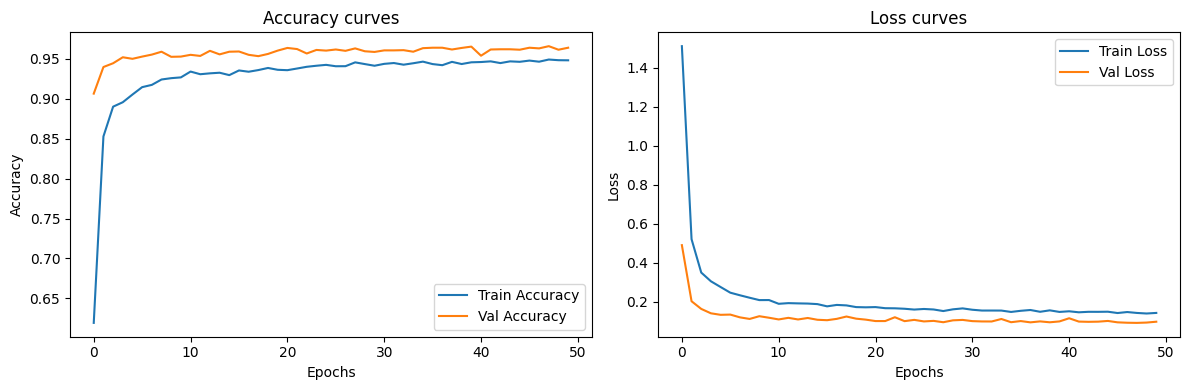

In [6]:
# Plot accuracy and loss curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### 6. Save Model and Training History
- Save Keras model as `.keras` file.
- Save history dict as `training_history.json`.

In [7]:
# Save the model
model.save('models/crop_recommendation_model.keras')
print("Model saved to 'models/crop_recommendation_model.keras'")

# Save training history
history_dict = history.history
# Convert float32 values to standard float for JSON serialization
for key in history_dict:
    history_dict[key] = [float(v) for v in history_dict[key]]

with open('models/training_history.json', 'w') as f:
    json.dump(history_dict, f, indent=4)

print("History saved to 'models/training_history.json'")

Model saved to 'models/crop_recommendation_model.keras'
History saved to 'models/training_history.json'
